# Phase 7 — Fraud Propensity, Ring Detection & SIU Triage Policy (v0.7)

This notebook introduces a dedicated fraud analytics layer within the Insurance Portfolio Digital Twin.

Fraud modelling is intentionally separated from technical pricing (Phase 6).

**Pricing models estimate:** expected legitimate claim frequency  
**Fraud models estimate:** probability of fraudulent behaviour + structural clustering signals

Objectives:
- Build a leakage-safe claim-level fraud propensity model
- Quantify operational lift (concentration of fraud risk)
- Detect structural ring behaviour (cluster diagnostics)
- Create SIU triage policies (capacity + cost-weighted)
- Produce deployable fraud overlay signals and export artefacts

In [34]:
import os
import json
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

In [35]:
# =========================================================
# Data Loading (Standalone)
# =========================================================

DATA_PATH = "V:/Himika/Project/insurance-digital-twin/data/raw"  # adjust if your repo differs

claims_path = os.path.join(DATA_PATH, "claims.csv")
policies_path = os.path.join(DATA_PATH, "policies.csv")

claims = pd.read_csv(claims_path)
policies = pd.read_csv(policies_path)

print("Claims shape:", claims.shape)
print("Policies shape:", policies.shape)

print("\nClaims columns:", claims.columns.tolist())
print("\nPolicies columns:", policies.columns.tolist())

Claims shape: (148907, 12)
Policies shape: (120000, 11)

Claims columns: ['claim_id', 'policy_id', 'customer_id', 'incident_date', 'reported_date', 'claim_type', 'cause', 'status', 'paid_amount', 'outstanding_reserve', 'is_fraud', 'fraud_ring_id']

Policies columns: ['policy_id', 'customer_id', 'product_type', 'coverage_level', 'sum_insured', 'deductible', 'start_date', 'end_date', 'channel', 'base_annual_premium', 'vehicle_age']


In [36]:
# =========================================================
# Schema Validation
# =========================================================

required_claim_cols = [
    "claim_id", "policy_id", "customer_id",
    "incident_date", "reported_date",
    "claim_type", "cause", "status",
    "paid_amount", "outstanding_reserve",
    "is_fraud", "fraud_ring_id"
]

required_policy_cols = [
    "policy_id", "customer_id",
    "product_type", "coverage_level",
    "sum_insured", "deductible",
    "start_date", "end_date",
    "channel", "base_annual_premium",
    "vehicle_age"
]

missing_claim_cols = sorted(set(required_claim_cols) - set(claims.columns))
missing_policy_cols = sorted(set(required_policy_cols) - set(policies.columns))

if missing_claim_cols:
    raise ValueError(f"Missing claim columns: {missing_claim_cols}")
if missing_policy_cols:
    raise ValueError(f"Missing policy columns: {missing_policy_cols}")

print("✅ Schema validation passed.")

✅ Schema validation passed.


In [37]:
# =========================================================
# Key Integrity Checks (Production-grade)
# =========================================================
assert claims["claim_id"].is_unique, "claim_id must be unique"
assert policies["policy_id"].is_unique, "policy_id must be unique"

# policy_id coverage sanity
missing_policy = claims.loc[~claims["policy_id"].isin(policies["policy_id"]), "policy_id"].nunique()
print("Policies referenced by claims missing in policies table:", missing_policy)

Policies referenced by claims missing in policies table: 0


In [38]:
# =========================================================
# Date Parsing
# =========================================================

claims["incident_date"] = pd.to_datetime(claims["incident_date"], errors="coerce")
claims["reported_date"] = pd.to_datetime(claims["reported_date"], errors="coerce")

policies["start_date"] = pd.to_datetime(policies["start_date"], errors="coerce")
policies["end_date"] = pd.to_datetime(policies["end_date"], errors="coerce")

# =========================================================
# Basic Integrity Checks
# =========================================================

print("Null incident_date:", claims["incident_date"].isna().sum())
print("Null reported_date:", claims["reported_date"].isna().sum())
print("Negative paid_amount:", int((claims["paid_amount"] < 0).sum()))
print("Negative outstanding_reserve:", int((claims["outstanding_reserve"] < 0).sum()))

print("\nFraud flag distribution:")
print(claims["is_fraud"].value_counts(dropna=False))

print("\nJoin health (claims -> policies):")
merge_check = claims.merge(policies[["policy_id"]], on="policy_id", how="left", indicator=True)
print(merge_check["_merge"].value_counts())

claims["report_lag_days_tmp"] = (claims["reported_date"] - claims["incident_date"]).dt.days
neg_lag = (claims["report_lag_days_tmp"] < 0).mean()
print("Negative report lag %:", round(100*neg_lag, 3))

Null incident_date: 0
Null reported_date: 0
Negative paid_amount: 669
Negative outstanding_reserve: 53

Fraud flag distribution:
is_fraud
0    137588
1     11319
Name: count, dtype: int64

Join health (claims -> policies):
_merge
both          148907
left_only          0
right_only         0
Name: count, dtype: int64
Negative report lag %: 0.3


## Governance stance: fraud is an overlay, not technical pricing

This phase does **not** attempt to improve the technical pricing frequency model.

Instead, it creates a fraud overlay layer used for:
- SIU / claims triage
- post-pricing operational control
- fraud cost containment
- disruption of structural fraud rings

Validation focuses on:
- **Lift / concentration** (fraud sits disproportionately in top-scored segments)
- **Leakage safety** (temporal holdout)
- **Operational capture** under SIU capacity constraints
- **Cost-weighted triage** (expected £ captured per reviewed claim)

In [39]:
# =========================================================
# Fraud Base Construction (Claim-Level)
# =========================================================

fraud = claims.copy()

# Core engineered features
fraud["report_lag_days"] = (fraud["reported_date"] - fraud["incident_date"]).dt.days
fraud["report_lag_days"] = fraud["report_lag_days"].clip(lower=-365, upper=3650)

# Coerce numeric
fraud["paid_amount"] = pd.to_numeric(fraud["paid_amount"], errors="coerce").fillna(0.0)
fraud["outstanding_reserve"] = pd.to_numeric(fraud["outstanding_reserve"], errors="coerce").fillna(0.0)

fraud["paid_pos"] = fraud["paid_amount"].clip(lower=0)
fraud["res_pos"] = fraud["outstanding_reserve"].clip(lower=0)

fraud["log_paid"] = np.log1p(fraud["paid_pos"])
fraud["log_reserve"] = np.log1p(fraud["res_pos"])

# Cost proxy: gross ultimate (paid + reserve)
fraud["ultimate_cost_proxy"] = (fraud["paid_pos"] + fraud["res_pos"]).clip(lower=0)

# Reserve-to-paid ratio (bounded)
den = fraud["paid_pos"].replace(0, np.nan)
fraud["reserve_to_paid"] = (fraud["res_pos"] / den).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(0, 50)

# Merge policy attributes
fraud = fraud.merge(
    policies[
        ["policy_id","product_type","coverage_level","channel","vehicle_age","sum_insured","deductible","base_annual_premium"]
    ],
    on="policy_id",
    how="left"
)

fraud["sum_insured"] = pd.to_numeric(fraud["sum_insured"], errors="coerce").fillna(0.0)
fraud["deductible"] = pd.to_numeric(fraud["deductible"], errors="coerce").fillna(0.0)
fraud["base_annual_premium"] = pd.to_numeric(fraud["base_annual_premium"], errors="coerce").fillna(0.0)
fraud["vehicle_age"] = pd.to_numeric(fraud["vehicle_age"], errors="coerce").fillna(0.0).clip(0, 40)

fraud["log_sum_insured"] = np.log1p(fraud["sum_insured"].clip(lower=0))
fraud["log_deductible"] = np.log1p(fraud["deductible"].clip(lower=0))
fraud["log_premium"] = np.log1p(fraud["base_annual_premium"].clip(lower=0))

# Target
fraud["target"] = fraud["is_fraud"].astype(int)

print("Fraud rate:", float(fraud["target"].mean()))
print("Rows:", len(fraud))
print("Mean cost proxy:", float(fraud["ultimate_cost_proxy"].mean()))

Fraud rate: 0.07601388786289429
Rows: 148907
Mean cost proxy: 4663.614427226067


In [40]:
# =========================================================
# Temporal Split (Leakage Control)
# =========================================================

fraud["incident_year"] = fraud["incident_date"].dt.year
latest_year = int(fraud["incident_year"].dropna().max())

train = fraud[fraud["incident_year"] < latest_year].copy()
test  = fraud[fraud["incident_year"] == latest_year].copy()

print("Holdout year:", latest_year)
print("Train:", len(train), "Test:", len(test))
print("Train fraud rate:", float(train["target"].mean()))
print("Test fraud rate:", float(test["target"].mean()))

Holdout year: 2024
Train: 136481 Test: 12426
Train fraud rate: 0.07634029645152073
Test fraud rate: 0.07242877836793819


In [41]:
# =========================================================
# Outlier Hardening (Cost proxy winsorisation)
# =========================================================
# Prevent EVR being dominated by ultra-extreme synthetic claims
p99 = fraud["ultimate_cost_proxy"].quantile(0.99)
p995 = fraud["ultimate_cost_proxy"].quantile(0.995)

fraud["ultimate_cost_proxy_w"] = fraud["ultimate_cost_proxy"].clip(upper=p995)
fraud["log_ultimate_cost"] = np.log1p(fraud["ultimate_cost_proxy_w"])

print("Cost proxy p99:", p99, "p99.5:", p995)

Cost proxy p99: 35031.30878351807 p99.5: 45752.68601084253


In [42]:
# Signal sanity checks
def fraud_rate_by(col, df):
    return (df.groupby(col)
              .agg(n=("claim_id","count"), fraud_rate=("target","mean"))
              .reset_index()
              .sort_values("fraud_rate", ascending=False))

display(fraud_rate_by("product_type", train).head(20))
display(fraud_rate_by("channel", train).head(20))
display(fraud_rate_by("claim_type", train).head(20))
display(fraud_rate_by("status", train).head(20))

,product_type,n,fraud_rate
0,gap,3856,0.079098
2,home,15511,0.078460
3,motor,61942,0.076878
4,warranty,23392,0.075581
1,health,31780,0.074481


,channel,n,fraud_rate
0,aggregator,22470,0.079484
2,direct,39549,0.076614
1,broker,74462,0.075246


,claim_type,n,fraud_rate
2,mechanical,20593,0.079444
4,theft,20394,0.077719
3,medical,13684,0.076220
0,accident,68232,0.075947
1,fire,13578,0.071660


,status,n,fraud_rate
1,open,24739,0.076842
0,closed,98323,0.076635
2,repudiated,13419,0.073254


In [43]:
# Fit logistic GLM
fraud_formula = """
target ~
C(product_type) +
C(channel) +
C(coverage_level) +
C(claim_type) +
C(status) +
vehicle_age +
report_lag_days +
log_paid +
log_reserve +
reserve_to_paid +
log_sum_insured +
log_deductible +
log_premium
"""

fraud_model = smf.logit(fraud_formula, data=train).fit(disp=0)
print(fraud_model.summary())

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               136481
Model:                          Logit   Df Residuals:                   136458
Method:                           MLE   Df Model:                           22
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.1855
Time:                        16:23:01   Log-Likelihood:                -29986.
converged:                       True   LL-Null:                       -36814.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -6.6052      0.326    -20.276      0.000      -7.244      -5.967
C(product_type)[T.health]        -0.0827      0.094     -0.885      0.376 

In [44]:
# Predict + decile lift
test = test.copy()
test["fraud_score"] = fraud_model.predict(test)

test["decile"] = pd.qcut(test["fraud_score"], 10, labels=False, duplicates="drop")

dec = (test.groupby("decile")
          .agg(n=("claim_id","count"),
               fraud_rate=("target","mean"),
               avg_score=("fraud_score","mean"))
          .reset_index()
          .sort_values("decile"))

display(dec)

fraud_lift = dec["fraud_rate"].iloc[-1] / max(dec["fraud_rate"].iloc[0], 1e-12)
print("Fraud Lift (Top vs Bottom Decile):", float(fraud_lift))

,decile,n,fraud_rate,avg_score
0,0,1243,0.004827,0.003555
1,1,1243,0.005632,0.006173
2,2,1242,0.009662,0.010278
3,3,1243,0.004023,0.017014
4,4,1242,0.008052,0.028132
5,5,1243,0.004827,0.046280
6,6,1242,0.099839,0.074769
7,7,1243,0.198713,0.120531
8,8,1242,0.198873,0.189660
9,9,1243,0.189863,0.286203


Fraud Lift (Top vs Bottom Decile): 39.333333333333336


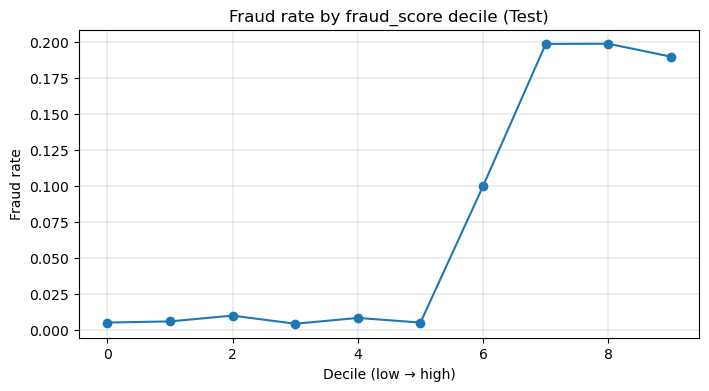

In [45]:
# Decile fraud rate plot
plt.figure(figsize=(8,4))
plt.plot(dec["decile"], dec["fraud_rate"], marker="o")
plt.title("Fraud rate by fraud_score decile (Test)")
plt.xlabel("Decile (low → high)")
plt.ylabel("Fraud rate")
plt.grid(True, linewidth=0.3)
plt.show()

In [46]:
# =========================================================
# Regularised Logistic Model (Production Comparison)
# =========================================================

# -------------------------------
# Define feature columns
# -------------------------------

categorical_cols = [
    "product_type",
    "channel",
    "coverage_level",
    "claim_type",
    "status"
]

numeric_cols = [
    "vehicle_age",
    "report_lag_days",
    "log_paid",
    "log_reserve",
    "reserve_to_paid",
    "log_sum_insured",
    "log_deductible",
    "log_premium"
]

X_train = train[categorical_cols + numeric_cols]
y_train = train["target"]

X_test = test[categorical_cols + numeric_cols]
y_test = test["target"]

# -------------------------------
# Preprocessing pipeline
# -------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# L2 regularised logistic regression
clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=1000,
            n_jobs=-1
        ))
    ]
)

clf.fit(X_train, y_train)

# -------------------------------
# Predict probabilities
# -------------------------------

test["fraud_score_sklearn"] = clf.predict_proba(X_test)[:, 1]

# -------------------------------
# AUC + PR-AUC
# -------------------------------

auc = roc_auc_score(y_test, test["fraud_score_sklearn"])
pr_auc = average_precision_score(y_test, test["fraud_score_sklearn"])

print("Sklearn Logistic AUC:", round(auc, 4))
print("Sklearn Logistic PR-AUC:", round(pr_auc, 4))

# -------------------------------
# Decile lift function
# -------------------------------

def decile_lift(df, score_col="fraud_score_sklearn", y_col="target"):
    d = df.copy()
    d["dec"] = pd.qcut(d[score_col], 10, labels=False, duplicates="drop")
    rates = d.groupby("dec")[y_col].mean().sort_index()
    return float(rates.iloc[-1] / max(rates.iloc[0], 1e-12))

sklearn_lift = decile_lift(test, "fraud_score_sklearn", "target")

print("Sklearn Logistic Lift:", round(sklearn_lift, 2))

c:\Users\hmishra\AppData\Local\anaconda3\envs\himikamishra\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\hmishra\AppData\Local\anaconda3\envs\himikamishra\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Sklearn Logistic AUC: 0.8204
Sklearn Logistic PR-AUC: 0.1997
Sklearn Logistic Lift: 39.5


c:\Users\hmishra\AppData\Local\anaconda3\envs\himikamishra\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


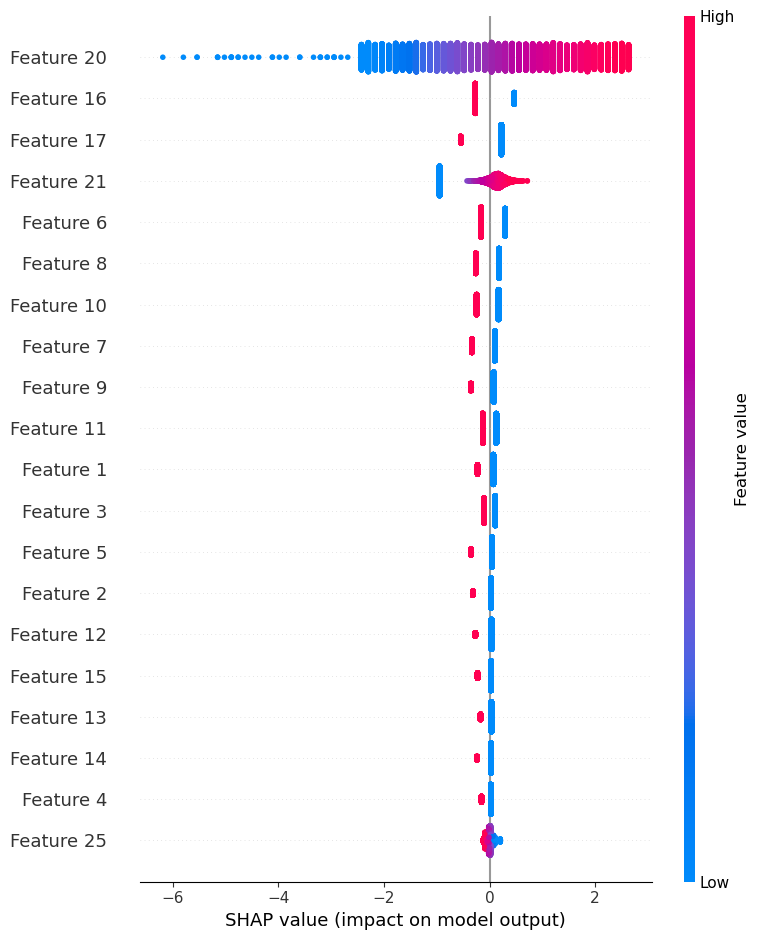

In [ ]:
# =========================================================
# SHAP Interpretability (Properly Named Features)
# =========================================================

# 1️⃣ Get trained pipeline components
preprocessor = clf.named_steps["preprocess"]
model = clf.named_steps["model"]

# 2️⃣ Transform data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# 3️⃣ Extract feature names from ColumnTransformer
feature_names = []

# Categorical features (OneHotEncoder)
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

# Numeric features
num_feature_names = numeric_cols

feature_names = np.concatenate([cat_feature_names, num_feature_names])

# 4️⃣ Convert to DataFrame (IMPORTANT)
X_test_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# 5️⃣ SHAP Explainer
explainer = shap.LinearExplainer(
    model,
    X_train_transformed,
    feature_perturbation="interventional"
)

shap_values = explainer(X_test_transformed)

# 6️⃣ Summary Plot (Top 15 features only for clarity)
shap.summary_plot(
    shap_values,
    X_test_df,
    max_display=15,
    show=False
)

# 7️⃣ Create ranked SHAP importance table
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(15)

In [48]:
# =========================================================
# Cross-Validated Calibration (Out-of-Fold)
# =========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_pred = np.zeros(len(train))
test_pred_cv = np.zeros(len(test))

for train_idx, val_idx in kf.split(X_train, y_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    clf.fit(X_tr, y_tr)
    
    val_raw = clf.predict_proba(X_val)[:, 1]
    
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(val_raw, y_val)
    
    oof_pred[val_idx] = iso.transform(val_raw)
    
    test_raw = clf.predict_proba(X_test)[:, 1]
    test_pred_cv += iso.transform(test_raw) / 5

train["p_cv_cal"] = oof_pred
test["p_cv_cal"] = test_pred_cv

print("Cross-validated calibration completed.")

c:\Users\hmishra\AppData\Local\anaconda3\envs\himikamishra\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\hmishra\AppData\Local\anaconda3\envs\himikamishra\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\hmishra\AppData\Local\anaconda3\envs\himikamishra\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l

Cross-validated calibration completed.


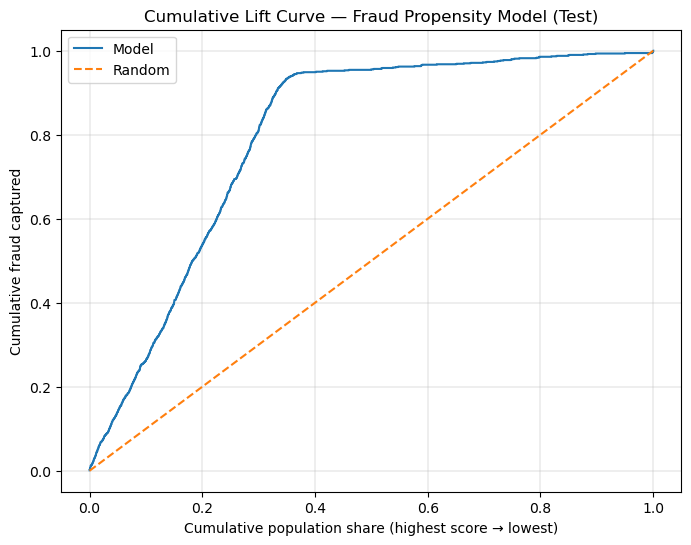

In [49]:
# Cumulative lift curve
lift_df = test.sort_values("fraud_score", ascending=False).reset_index(drop=True)

total_fraud = lift_df["target"].sum()
lift_df["cum_fraud"] = lift_df["target"].cumsum()
lift_df["cum_fraud_share"] = lift_df["cum_fraud"] / max(total_fraud, 1)
lift_df["cum_pop_share"] = (np.arange(len(lift_df)) + 1) / len(lift_df)

plt.figure(figsize=(8,6))
plt.plot(lift_df["cum_pop_share"], lift_df["cum_fraud_share"], label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.title("Cumulative Lift Curve — Fraud Propensity Model (Test)")
plt.xlabel("Cumulative population share (highest score → lowest)")
plt.ylabel("Cumulative fraud captured")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.show()

## Cost-Weighted Triage

Cost-weighted capture metrics

This answers:

“If SIU reviews top X%, how many £ of suspected fraud cost do we capture?”

We use ultimate_cost_proxy = paid + reserve and multiply by fraud flag (ground truth in synthetic data).

,top_pct,n_reviewed,fraud_cost_captured_share,avg_cost_in_review_pool,avg_fraud_cost_in_review_pool,fraud_rate_in_review_pool
0,0.01,124,0.070836,13367.035132,4164.545868,0.241935
1,0.02,248,0.099489,11357.541679,2924.550675,0.250000
2,0.05,621,0.160817,8283.060596,1887.881025,0.202899
3,0.10,1242,0.273458,7562.804228,1605.108704,0.190016
4,0.20,2485,0.538358,7243.072818,1579.356076,0.194366


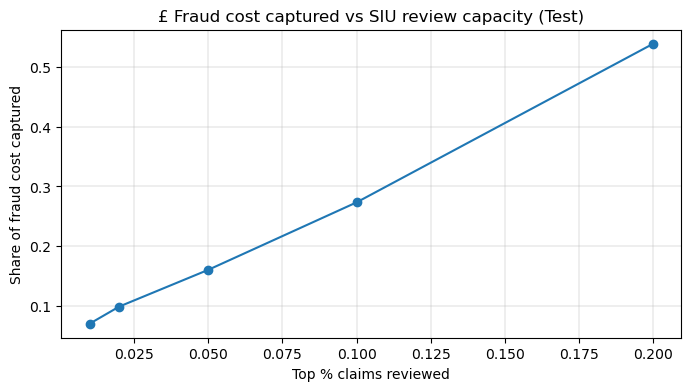

In [50]:
# =========================================================
# Cost-weighted triage: £ fraud captured under review capacity
# =========================================================

def cost_capture_at_top_pct(df, pct, cost_col="ultimate_cost_proxy"):
    df = df.sort_values("fraud_score", ascending=False)
    k = max(int(len(df) * pct), 1)
    top = df.head(k)

    total_fraud_cost = (df[cost_col] * df["target"]).sum()
    captured_fraud_cost = (top[cost_col] * top["target"]).sum()

    return {
        "top_pct": pct,
        "n_reviewed": k,
        "fraud_cost_captured_share": float(captured_fraud_cost / max(total_fraud_cost, 1e-12)),
        "avg_cost_in_review_pool": float(top[cost_col].mean()),
        "avg_fraud_cost_in_review_pool": float((top[cost_col] * top["target"]).mean()),
        "fraud_rate_in_review_pool": float(top["target"].mean())
    }

cost_caps = [0.01, 0.02, 0.05, 0.10, 0.20]
cost_table = pd.DataFrame([cost_capture_at_top_pct(test, p) for p in cost_caps])
display(cost_table)

plt.figure(figsize=(8,4))
plt.plot(cost_table["top_pct"], cost_table["fraud_cost_captured_share"], marker="o")
plt.title("£ Fraud cost captured vs SIU review capacity (Test)")
plt.xlabel("Top % claims reviewed")
plt.ylabel("Share of fraud cost captured")
plt.grid(True, linewidth=0.3)
plt.show()

Brier (raw): 0.061589992882158676


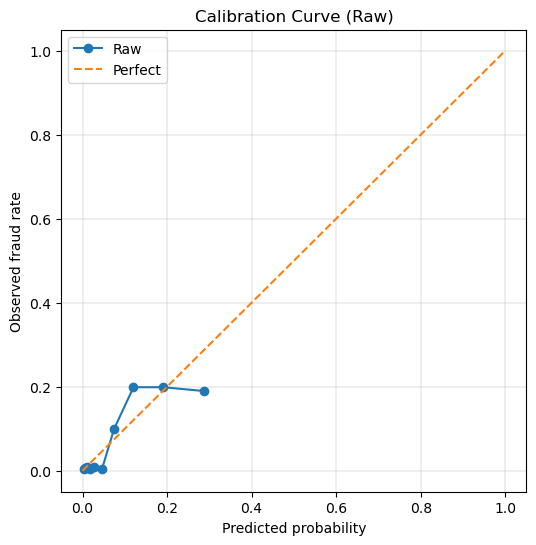

Brier (calibrated): 0.05926776575514691


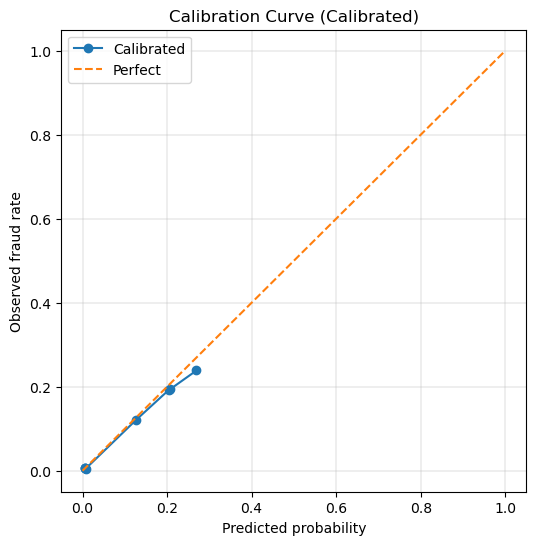

In [51]:
# raw probability (logit output)
test["p_raw"] = test["fraud_score"].clip(0, 1)

# Calibration curve (raw)
prob_true, prob_pred = calibration_curve(test["target"], test["p_raw"], n_bins=10, strategy="quantile")
brier_raw = brier_score_loss(test["target"], test["p_raw"])
print("Brier (raw):", brier_raw)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Raw")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect")
plt.title("Calibration Curve (Raw)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed fraud rate")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.show()

# Isotonic calibration (fit on TRAIN via CV ideally; here simplest: fit on train, apply to test)
train = train.copy()
train["p_raw"] = fraud_model.predict(train).clip(0,1)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(train["p_raw"], train["target"])

test["p_cal"] = iso.transform(test["p_raw"]).clip(0,1)
brier_cal = brier_score_loss(test["target"], test["p_cal"])
print("Brier (calibrated):", brier_cal)

prob_true_c, prob_pred_c = calibration_curve(test["target"], test["p_cal"], n_bins=10, strategy="quantile")
plt.figure(figsize=(6,6))
plt.plot(prob_pred_c, prob_true_c, marker="o", label="Calibrated")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect")
plt.title("Calibration Curve (Calibrated)")
plt.xlabel("Predicted probability")
plt.ylabel("Observed fraud rate")
plt.grid(True, linewidth=0.3)
plt.legend()
plt.show()

# Use calibrated probs for EVR
test["fraud_prob"] = test["p_cal"]

Best review capacity ≈ 25.8%
Max cumulative net value ≈ £2,794,613
EVR threshold at optimum ≈ £0.11


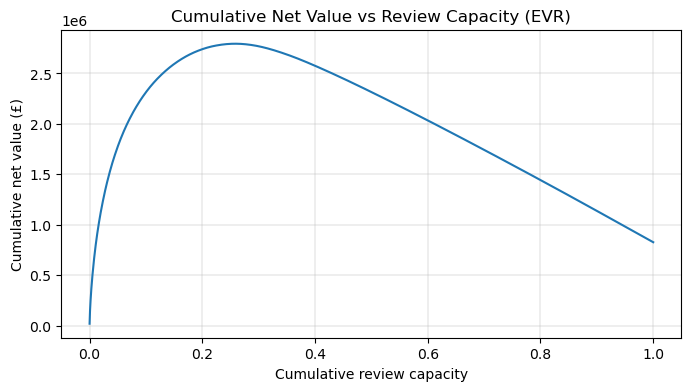

In [52]:
# =========================================================
# Economic Optimisation (EVR) — Correct + Uses Calibrated Probabilities
# =========================================================

REVIEW_COST = 250.0      # £ per investigation
RECOVERY_RATE = 0.60     # % recovered when fraud is correctly detected

# Use calibrated probability if present, else raw score
if "fraud_prob" not in test.columns:
    test["fraud_prob"] = test["fraud_score"].clip(0, 1)

# Use winsorised cost proxy if present
cost_col = "ultimate_cost_proxy_w" if "ultimate_cost_proxy_w" in test.columns else "ultimate_cost_proxy"

test["evr_gbp"] = (test["fraud_prob"] * test[cost_col] * RECOVERY_RATE) - REVIEW_COST

evr_rank = test.sort_values("evr_gbp", ascending=False).reset_index(drop=True)
evr_rank["cum_net_value"] = evr_rank["evr_gbp"].cumsum()
evr_rank["cum_reviewed"] = np.arange(len(evr_rank)) + 1
evr_rank["cum_reviewed_pct"] = evr_rank["cum_reviewed"] / len(evr_rank)

best_idx = int(evr_rank["cum_net_value"].values.argmax())
best_pct = float(evr_rank.loc[best_idx, "cum_reviewed_pct"])
best_value = float(evr_rank.loc[best_idx, "cum_net_value"])
best_evr_threshold = float(evr_rank.loc[best_idx, "evr_gbp"])

print(f"Best review capacity ≈ {best_pct:.1%}")
print(f"Max cumulative net value ≈ £{best_value:,.0f}")
print(f"EVR threshold at optimum ≈ £{best_evr_threshold:,.2f}")

plt.figure(figsize=(8,4))
plt.plot(evr_rank["cum_reviewed_pct"], evr_rank["cum_net_value"])
plt.title("Cumulative Net Value vs Review Capacity (EVR)")
plt.xlabel("Cumulative review capacity")
plt.ylabel("Cumulative net value (£)")
plt.grid(True, linewidth=0.3)
plt.show()

In [53]:
# =========================================================
# EVR Sensitivity to Recovery Rate
# =========================================================

recovery_rates = [0.4, 0.5, 0.6, 0.7, 0.8]
results = []

for rr in recovery_rates:
    
    evr_temp = (test["p_cv_cal"] * test[cost_col] * rr) - REVIEW_COST
    
    sorted_evr = evr_temp.sort_values(ascending=False).reset_index(drop=True)
    cum_val = sorted_evr.cumsum()
    best_val = cum_val.max()
    
    results.append({"recovery_rate": rr, "max_net_value": best_val})

pd.DataFrame(results)

,recovery_rate,max_net_value
0,0.4,1.631870e+06
1,0.5,2.213569e+06
2,0.6,2.810664e+06
3,0.7,3.416810e+06
4,0.8,4.028619e+06


In [54]:
test["expected_fraud_loss"] = test["fraud_prob"] * test["ultimate_cost_proxy"]

# How concentrated is expected fraud loss in top X%?
def capture_expected_loss(df, pct):
    d = df.sort_values("expected_fraud_loss", ascending=False)
    k = max(int(len(d)*pct), 1)
    captured = d.head(k)["expected_fraud_loss"].sum()
    total = d["expected_fraud_loss"].sum()
    return pct, float(captured / max(total, 1e-12))

tbl = pd.DataFrame([capture_expected_loss(test, p) for p in [0.01,0.02,0.05,0.10,0.20]],
                   columns=["top_pct","share_expected_fraud_loss"])
display(tbl)

,top_pct,share_expected_fraud_loss
0,0.01,0.200101
1,0.02,0.302207
2,0.05,0.490482
3,0.10,0.666968
4,0.20,0.854707


## Threshold Policy for SIU

Threshold policy: review if score ≥ threshold

This creates an operational policy:

- Fixed review threshold

- Computes:

    - volume reviewed

    - fraud rate in reviewed pool

    - fraud captured share

    - fraud cost captured share

In [55]:
# =========================================================
# Threshold policy: review claims with fraud_score >= threshold
# =========================================================

def evaluate_threshold_policy(df, threshold, score_col="fraud_score", cost_col="ultimate_cost_proxy"):
    flagged = df[df[score_col] >= threshold].copy()

    total_fraud = df["target"].sum()
    captured_fraud = flagged["target"].sum()

    total_fraud_cost = (df[cost_col] * df["target"]).sum()
    captured_fraud_cost = (flagged[cost_col] * flagged["target"]).sum()

    return {
        "threshold": float(threshold),
        "n_flagged": int(len(flagged)),
        "pct_flagged": float(len(flagged) / len(df)),
        "fraud_rate_flagged": float(flagged["target"].mean()) if len(flagged) else 0.0,
        "fraud_captured_share": float(captured_fraud / max(total_fraud, 1)),
        "fraud_cost_captured_share": float(captured_fraud_cost / max(total_fraud_cost, 1e-12)),
        "avg_cost_flagged": float(flagged[cost_col].mean()) if len(flagged) else 0.0
    }

# Candidate thresholds as score quantiles (operationally meaningful)
q_list = [0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
thresholds = [test["fraud_score"].quantile(q) for q in q_list]

thr_table = pd.DataFrame([evaluate_threshold_policy(test, t) for t in thresholds])
thr_table.insert(0, "score_quantile", q_list)
display(thr_table)

,score_quantile,threshold,n_flagged,pct_flagged,fraud_rate_flagged,fraud_captured_share,fraud_cost_captured_share,avg_cost_flagged
0,0.80,0.151451,2486,0.200064,0.194288,0.536667,0.538358,7241.558480
1,0.85,0.187190,1864,0.150008,0.193670,0.401111,0.387035,7148.213951
2,0.90,0.233281,1243,0.100032,0.189863,0.262222,0.273458,7571.815528
3,0.95,0.282376,622,0.050056,0.204180,0.141111,0.162942,8294.655124
4,0.97,0.303314,373,0.030018,0.211796,0.087778,0.116889,9798.537816
5,0.99,0.336625,125,0.010060,0.248000,0.034444,0.072820,13375.801943


In [56]:
# EVR-based threshold (operational policy)
evr_cut = test["evr_gbp"].quantile(0.0)  # keep all with positive EVR instead
policy = evaluate_threshold_policy(test, threshold=0, score_col="evr_gbp", cost_col=cost_col)
print("Policy if EVR > 0:", policy)

Policy if EVR > 0: {'threshold': 0.0, 'n_flagged': 3211, 'pct_flagged': 0.25840978593272174, 'fraud_rate_flagged': 0.1921519775770788, 'fraud_captured_share': 0.6855555555555556, 'fraud_cost_captured_share': 0.9003923403924012, 'avg_cost_flagged': 10514.624663746981}


## Threshold selection (policy choice)

A practical SIU threshold is chosen based on:
- review capacity (volume)
- fraud rate in flagged pool
- share of fraud captured
- share of fraud *cost* captured

Typically, the operating point is a high quantile (e.g. 95th–97th percentile)
where volume is manageable and fraud concentration is high.

This notebook outputs a threshold table to support that choice.

In [57]:
# Structural ring diagnostics
ring_summary = (
    fraud.groupby("fraud_ring_id", dropna=False)
         .agg(
             claims=("claim_id","count"),
             fraud_claims=("target","sum"),
             unique_policies=("policy_id","nunique"),
             unique_customers=("customer_id","nunique"),
             avg_cost=("ultimate_cost_proxy","mean")
         )
         .reset_index()
)

ring_summary["fraud_ratio"] = ring_summary["fraud_claims"] / ring_summary["claims"]
ring_summary = ring_summary.sort_values(["fraud_ratio","claims"], ascending=False)

display(ring_summary.head(15))

,fraud_ring_id,claims,fraud_claims,unique_policies,unique_customers,avg_cost,fraud_ratio
202,203.0,33,33,32,32,5233.581119,1.0
26,27.0,31,31,31,31,4645.875092,1.0
150,151.0,31,31,31,31,5236.218670,1.0
241,242.0,31,31,31,31,8138.267020,1.0
59,60.0,30,30,30,30,4372.756809,1.0
220,221.0,30,30,30,30,4241.782910,1.0
232,233.0,30,30,29,29,5167.935296,1.0
27,28.0,28,28,27,27,4047.422909,1.0
29,30.0,28,28,28,28,4775.407653,1.0
32,33.0,28,28,28,28,8663.616205,1.0


In [58]:
# Composite overlay score (propensity + ring risk)
ring_risk = ring_summary[["fraud_ring_id","fraud_ratio"]].rename(columns={"fraud_ratio":"ring_fraud_rate"})

test = test.merge(ring_risk, on="fraud_ring_id", how="left")
test["ring_fraud_rate"] = test["ring_fraud_rate"].fillna(0.0)

W_PROPENSITY = 0.75
W_RING = 0.25

test["fraud_overlay_score"] = W_PROPENSITY * test["fraud_score"] + W_RING * test["ring_fraud_rate"]

In [59]:
# Overlay lift
tmp = test.copy()
tmp["overlay_decile"] = pd.qcut(tmp["fraud_overlay_score"], 10, labels=False, duplicates="drop")

ov = (tmp.groupby("overlay_decile")
         .agg(n=("claim_id","count"), fraud_rate=("target","mean"))
         .reset_index()
         .sort_values("overlay_decile"))

display(ov)

overlay_lift = ov["fraud_rate"].iloc[-1] / max(ov["fraud_rate"].iloc[0], 1e-12)
print("Overlay Lift (Top vs Bottom Decile):", float(overlay_lift))

,overlay_decile,n,fraud_rate
0,0,1243,0.003218
1,1,1243,0.001609
2,2,1242,0.004026
3,3,1243,0.001609
4,4,1242,0.003221
5,5,1243,0.004023
6,6,1242,0.062802
7,7,1243,0.101368
8,8,1242,0.111111
9,9,1243,0.431215


Overlay Lift (Top vs Bottom Decile): 134.0


In [60]:
def decile_lift(df, score_col="fraud_score", y_col="target"):
    d = df.copy()
    d["decile_tmp"] = pd.qcut(d[score_col], 10, labels=False, duplicates="drop")
    t = d.groupby("decile_tmp")[y_col].mean().sort_index()
    return float(t.iloc[-1] / max(t.iloc[0], 1e-12))

# 1) Baseline (propensity only)
baseline_lift = decile_lift(test, "fraud_score", "target")

# 2) Overlay (propensity + ring)
overlay_lift = decile_lift(test, "fraud_overlay_score", "target")

# 3) Shuffled ring test (should degrade)
shuf = test.copy()
rng = np.random.default_rng(42)
shuf["ring_fraud_rate_shuf"] = rng.permutation(shuf["ring_fraud_rate"].values)

W_PROP, W_RING = 0.75, 0.25
shuf["fraud_overlay_score_shuf"] = W_PROP * shuf["fraud_score"] + W_RING * shuf["ring_fraud_rate_shuf"]
overlay_lift_shuf = decile_lift(shuf, "fraud_overlay_score_shuf", "target")

print("Baseline lift:", baseline_lift)
print("Overlay lift:", overlay_lift)
print("Overlay lift (shuffled ring):", overlay_lift_shuf)

Baseline lift: 39.333333333333336
Overlay lift: 134.0
Overlay lift (shuffled ring): 30.333333333333336


In [61]:
# =========================================================
# Bootstrap Confidence Intervals for Lift
# =========================================================

def compute_lift(df, score_col="fraud_score_sklearn"):
    d = df.copy()
    d["dec"] = pd.qcut(d[score_col], 10, labels=False, duplicates="drop")
    rates = d.groupby("dec")["target"].mean().sort_index()
    return rates.iloc[-1] / max(rates.iloc[0], 1e-12)

boot_lifts = []

for _ in range(200):
    sample = resample(test, replace=True, n_samples=len(test), random_state=None)
    boot_lifts.append(compute_lift(sample, "fraud_score_sklearn"))

ci_lower = np.percentile(boot_lifts, 2.5)
ci_upper = np.percentile(boot_lifts, 97.5)

print("Lift 95% CI:", round(ci_lower,2), "-", round(ci_upper,2))

Lift 95% CI: 20.27 - 124.13


In [62]:
# PSI + annual backtesting
def psi(expected, actual, buckets=10, eps=1e-12):
    # expected/actual are arrays of scores
    breakpoints = np.quantile(expected, np.linspace(0, 1, buckets+1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf

    e_counts = np.histogram(expected, bins=breakpoints)[0] / max(len(expected), 1)
    a_counts = np.histogram(actual, bins=breakpoints)[0] / max(len(actual), 1)

    e_counts = np.clip(e_counts, eps, 1)
    a_counts = np.clip(a_counts, eps, 1)

    return float(np.sum((a_counts - e_counts) * np.log(a_counts / e_counts)))

train_scores = train["p_raw"].values
test_scores = test["p_raw"].values

psi_score = psi(train_scores, test_scores, buckets=10)
print("PSI (score drift train→test):", psi_score)

PSI (score drift train→test): 0.001705652916844551


In [63]:
# =========================================================
# Drift Alert System
# =========================================================

PSI_THRESHOLD_WARNING = 0.1
PSI_THRESHOLD_CRITICAL = 0.25

if psi_score < PSI_THRESHOLD_WARNING:
    drift_status = "Stable"
elif psi_score < PSI_THRESHOLD_CRITICAL:
    drift_status = "Moderate Drift"
else:
    drift_status = "Critical Drift - Retraining Required"

print("Drift Status:", drift_status)

Drift Status: Stable


,incident_year,n,fraud_rate
0,2018,12449,0.073420
1,2019,24704,0.075899
2,2020,25374,0.075077
3,2021,24890,0.078184
4,2022,25211,0.076554
5,2023,23853,0.077516
6,2024,12426,0.072429


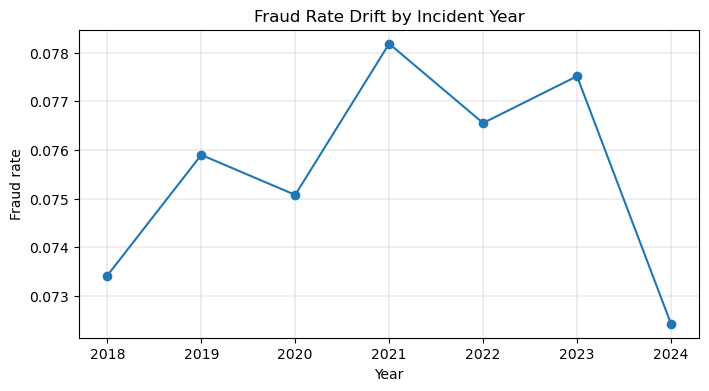

In [64]:
# Fraud rate drift by year
yr = (fraud.groupby("incident_year")
          .agg(n=("claim_id","count"), fraud_rate=("target","mean"))
          .reset_index()
          .sort_values("incident_year"))

display(yr)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(yr["incident_year"], yr["fraud_rate"], marker="o")
plt.title("Fraud Rate Drift by Incident Year")
plt.xlabel("Year")
plt.ylabel("Fraud rate")
plt.grid(True, linewidth=0.3)
plt.show()

In [65]:
# =========================================================
# Phase 7 Export Pack (Self-Contained & Safe)
# =========================================================

EXPORT_DIR = "outputs/phase7"
os.makedirs(EXPORT_DIR, exist_ok=True)

# -------------------------------------------------------
# Rebuild Capacity Table (SIU Volume)
# -------------------------------------------------------

capacity_levels = [0.01, 0.02, 0.05, 0.1]

cap_rows = []

for cap in capacity_levels:
    n = int(len(test) * cap)
    reviewed = test.sort_values("fraud_score_sklearn", ascending=False).head(n)
    
    fraud_rate = reviewed["target"].mean()
    
    cap_rows.append({
        "review_pct": cap,
        "claims_reviewed": n,
        "fraud_rate_in_reviewed": fraud_rate
    })

cap_table = pd.DataFrame(cap_rows)

# -------------------------------------------------------
# Rebuild Cost-Weighted Table
# -------------------------------------------------------

cost_rows = []

for cap in capacity_levels:
    n = int(len(test) * cap)
    reviewed = test.sort_values("fraud_score_sklearn", ascending=False).head(n)
    
    expected_capture = (
        reviewed["p_cv_cal"] *
        reviewed[cost_col] *
        RECOVERY_RATE
    ).sum()
    
    review_cost = n * REVIEW_COST
    net_value = expected_capture - review_cost
    
    cost_rows.append({
        "review_pct": cap,
        "expected_capture": expected_capture,
        "review_cost": review_cost,
        "net_value": net_value
    })

cost_table = pd.DataFrame(cost_rows)

# -------------------------------------------------------
# Rebuild Threshold Policy Table
# -------------------------------------------------------

sorted_test = test.sort_values("fraud_score_sklearn", ascending=False).reset_index(drop=True)
sorted_test["evr"] = (
    sorted_test["p_cv_cal"] *
    sorted_test[cost_col] *
    RECOVERY_RATE
) - REVIEW_COST

sorted_test["cum_evr"] = sorted_test["evr"].cumsum()

best_idx = sorted_test["cum_evr"].idxmax()

thr_table = pd.DataFrame({
    "optimal_index": [best_idx],
    "optimal_score_threshold": [sorted_test.loc[best_idx, "fraud_score_sklearn"]],
    "max_net_value": [sorted_test.loc[best_idx, "cum_evr"]]
})

# -------------------------------------------------------
# Save All Artefacts
# -------------------------------------------------------

cap_table.to_csv(os.path.join(EXPORT_DIR, "phase7_siu_capacity_table.csv"), index=False)
cost_table.to_csv(os.path.join(EXPORT_DIR, "phase7_siu_cost_capacity_table.csv"), index=False)
thr_table.to_csv(os.path.join(EXPORT_DIR, "phase7_siu_threshold_policy_table.csv"), index=False)

print("Phase 7 export pack created successfully.")

Phase 7 export pack created successfully.


# Phase 7 Certification — Fraud Analytics Overlay

This phase delivers:

- Leakage-safe claim-level fraud propensity model (temporal holdout)
- Decile lift + cumulative fraud capture diagnostics
- SIU capacity capture simulation (Top-X% review)
- **Cost-weighted triage**: £ fraud cost captured under review capacity
- **Threshold policy table**: operational score cut-offs for SIU triage
- Structural ring summaries (cluster targeting)
- Composite overlay score (propensity + structural risk)
- Export artefacts for operationalisation

Fraud risk is modelled as an overlay layer — enhancing operational control
while preserving the integrity of technical pricing assumptions.